In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
from pathlib import Path
import pickle
import operator

import numpy as np
import scipy as sp
from openmm.app import PDBFile
from openbabel import pybel
import pandas as pd
from pdbfixer import PDBFixer

import sciapi
import scids
import scifile
import scishow
import caddpy

Define paths for storing intermediate results:

In [3]:
project_id = "3w32"

cache_dir = Path(f".tmp/{project_id}")
assert " " not in str(cache_dir), "autogrid does not accept whitespace in paths"
pdb_filepath_raw = cache_dir / "receptor_raw.pdb"
pdb_filepath_fixed = cache_dir / "receptor_fixed.pdb"
pdb_filepath_apo = cache_dir / "receptor_fixed_apo.pdb"
pdbqt_filepath = cache_dir / "receptor.pdbqt"
pockets_filepath = cache_dir / "pockets.pkl"
autogrid_dirpath = cache_dir/ "autogrid"
autogrid_common_path = autogrid_dirpath / project_id
gpf_filepath = autogrid_common_path.with_suffix(".gpf")
cache_dir.mkdir(exist_ok=True, parents=True)
autogrid_dirpath.mkdir(exist_ok=True, parents=True)

## Structure Preparation

Obtain a PDB file:

In [4]:
pdb_id = project_id

if not pdb_filepath_raw.is_file():
    pdb_file_content = sciapi.pdb.file.entry(pdb_id=pdb_id, file_format="pdb")
    pdb_filepath_raw.write_bytes(pdb_file_content)

Fix the PDB file:

In [5]:
if not pdb_filepath_fixed.is_file():
    fixer = PDBFixer(filename=str(pdb_filepath_raw))
    fixer.findMissingResidues()
    fixer.findNonstandardResidues()
    fixer.replaceNonstandardResidues()
    fixer.findMissingAtoms()
    fixer.addMissingAtoms()
    fixer.addMissingHydrogens(7.0)
    PDBFile.writeFile(fixer.topology, fixer.positions, open(pdb_filepath_fixed, 'w'))

We store one fixed PDB with ligands, and one without.
The one with ligands is used later as reference for visualization and validation.
The one without ligands is used to create a PDBQT file for AutoGrid:

In [6]:
if not pdb_filepath_apo.is_file():
    fixer = PDBFixer(filename=str(pdb_filepath_fixed))
    fixer.removeHeterogens(False)
    PDBFile.writeFile(fixer.topology, fixer.positions, open(pdb_filepath_apo, 'w'))

Create the PDBQT file from the cleaned and fixed PDB file:

In [7]:
if not pdbqt_filepath.is_file():
    molecule = next(pybel.readfile("pdb", str(pdb_filepath_apo)))
    molecule.calccharges("gasteiger")
    molecule.write(
        format="pdbqt",
        filename=str(pdbqt_filepath),
        overwrite=True,
        opt={"r": None, "n": None, "p": None, "h": None},
    )


Read the created PDBQT file (used later for atom type references):

In [8]:
pdbqt_file = scifile.autodock_pdbqt.read(pdbqt_filepath)

/Volumes/T7/repo/gh/aariam/opencadd/scifile/pkg/src/scifile/pdb/parser.py:144: UserWarning: Error parsing record remark: invalid literal for int() with base 10: np.str_('Na')
  warnings.warn(
/Volumes/T7/repo/gh/aariam/opencadd/scifile/pkg/src/scifile/pdb/parser.py:144: UserWarning: Error parsing record cryst1: 'NoneType' object is not subscriptable
  warnings.warn(


## Binding Site Detection

Use DoGSiteScorer to detect binding sites (this is the longest step, taking ca. 1-2 min):

In [9]:
if not pockets_filepath.is_file():
    protplus_upload_results = sciapi.proteinsplus().upload_pdb(pdb_filepath_fixed.read_bytes())
    dogsite_results = sciapi.proteinsplus().dogsite(
        pdb_id=protplus_upload_results.dummy_pdb_id,
        algorithm="scorer",
    )
    binding_sites = dogsite_results.full_data
    with open(pockets_filepath, "wb") as f:
        pickle.dump(binding_sites, f)
else:
    with open(pockets_filepath, "rb") as f:
        binding_sites = pickle.load(f)

Select the best binding pocket.
Here we select the binding pocket with a volume less than 1000 Å^3 and highest score:

In [10]:
binding_site_df = pd.DataFrame(binding_sites)
idx_selected_pocket = binding_site_df[binding_site_df["volume"] < 1000]["simpleScore"].idxmax()
binding_site_df.loc[idx_selected_pocket, "name"]

'P_0_0'

Read the volume map for the selected pocket:

In [11]:
pocket = scifile.mrc.read(binding_site_df.loc[idx_selected_pocket, "mrc"])
pocket

MrcFile(
   n_xyz      = [49 36 47]
   mode       = 2
   nstart_xyz = [22 57  3]
   m_xyz      = [48 35 46]
   cell_a     = [20.582333 15.007952 19.724737]
   cell_b     = [90. 90. 90.]
   map_xyz    = (1, 2, 3)
   dmin       = 0.0
   dmax       = 1.0
   dmean      = 0.13096444308757782
   ispg       = 1
   nsymbt     = 0
   extra      = b''
   exttyp     = ""
   nversion   = 0
   extra2     = b''
   origin     = [0. 0. 0.]
   rms        = 0.3373614549636841
   nlabl      = 1
   labels     = ["CCP4 File written with NAOMI."]
)

Create a `Grid` from the map data:

In [12]:
grid = scids.grid.from_shape_spacing_anchor(
    shape=pocket.n_xyz,
    spacing=pocket.grid_vectors[0][0],
    anchor_type="lower",
    anchor_coord=pocket.grid_origin,
)
grid

Grid(
  shape=[49 36 47],
  size=[20.58233261 15.00795086 19.72473542],
  spacings=[0.4287986 0.4287986 0.4287986],
  lower_bounds=[ 9.43356799 24.44152134  1.2863959 ],
  center=[19.72473429 31.94549677 11.14876361],
  upper_bounds=[30.0159006  39.44947221 21.01113132]
)

## Energy Calculation

In [13]:
ligand_types = ("C", "HD", "OA")
field_names = ligand_types + ("e", "d")
mif = caddpy.mif.autogrid.from_pdbqt(
    files=pdbqt_filepath,
    grid=grid,
    ligand_types=ligand_types,
    output_dir=autogrid_dirpath,
)

Plot energy distributions:

In [14]:
field_colors = {
    "c":  [255, 165, 0],     # Hydrophobic (Orange)
    "a":  [128, 0, 128],     # Aromatic (Purple)
    "hd": [0, 255, 255],     # H-bond Donor (Cyan)
    "n":  [0, 0, 255],       # Non-Hbonding Nitrogen (Blue)
    "na": [30, 144, 255],    # H-bonding Nitrogen (Dodger Blue)
    "oa": [0, 128, 0],       # H-bonding Oxygen (Green)
    "sa": [255, 20, 147],    # H-bonding Sulphur (Deep Pink)
    "e":  [255, 0, 0],       # Electrostatic (Red)
    "d":  [255, 215, 0],     # Desolvation (Gold)
    "pi": [255, 0, 0],
    "ni": [0, 0, 255],
}

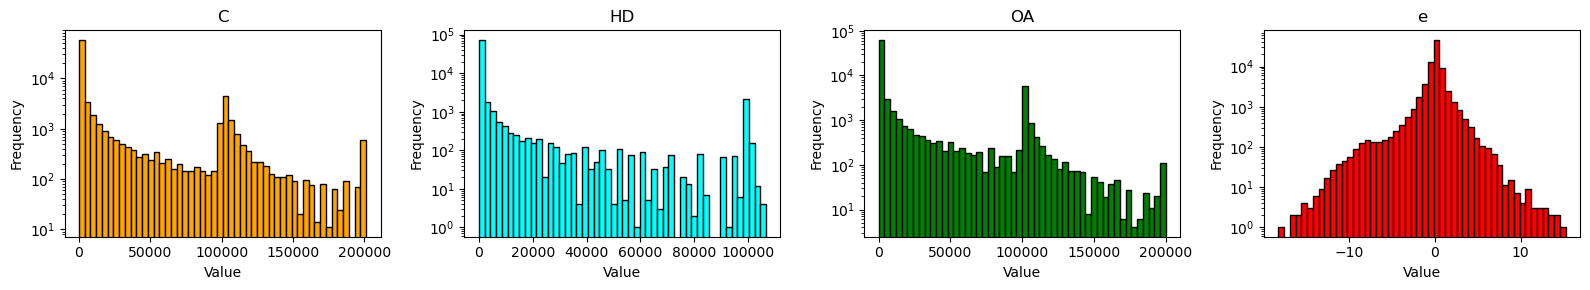

In [15]:
scishow.matplotlib.Plotter(
).add_histograms(
    data=mif.tensor[:-1],
    axes=0,
    names=field_names[:-1],
    colors=[field_colors[field_name.lower()] for field_name in field_names[:-1]]
).show()

In [16]:
tensor = np.array(mif.tensor)
tensor[:, pocket.data == 0] = np.nan

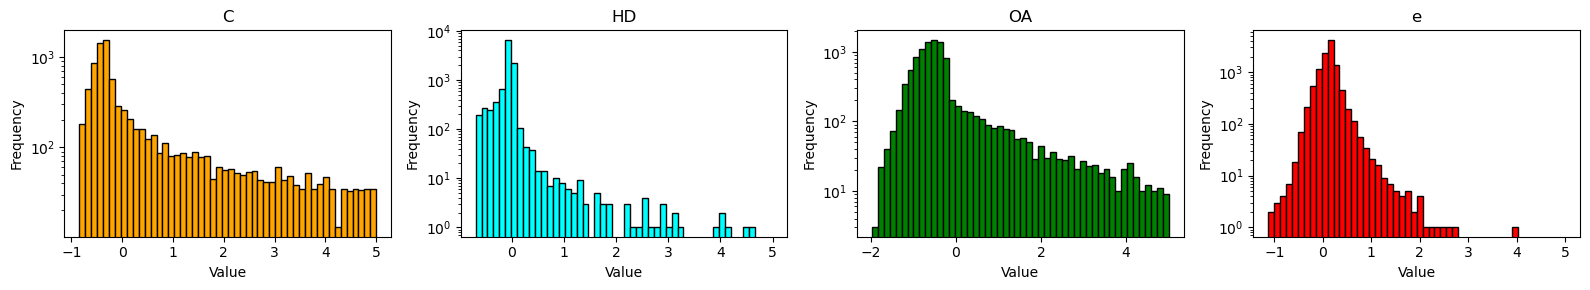

In [17]:
scishow.matplotlib.Plotter(
).add_histograms(
    data=tensor[:-1],
    axes=0,
    names=field_names[:-1],
    colors=[field_colors[field_name.lower()] for field_name in field_names[:-1]],
    bin_range=(None, 5)
).show()

## Feature Selection

Use the pocket volume as a mask and set everything outside of it equal zero:

In [18]:
mask_site = pocket.data == 1

Define selection criteria:

In [19]:
field_names = ligand_types + ("PI", "NI")
field_indices = (0, 1, 2, 3, 3)
field_cutoffs = (-0.4, -0.35, -0.6, -1, 1)
cutoff_operators = (operator.lt, operator.lt, operator.lt, operator.lt, operator.gt)
structure = np.ones((3, 3, 3), dtype=int)  # full 26-connectivity

Generate features:

In [20]:
features = []
for field_name, field_idx, field_cutoff, cutoff_operator in zip(field_names, field_indices, field_cutoffs, cutoff_operators):
    mask_field = cutoff_operator(mif.tensor[field_idx], field_cutoff)
    mask_final = np.logical_and(mask_field, mask_site)
    labeled_array, num_features = sp.ndimage.label(mask_final, structure=structure)
    if num_features == 0:
        continue
    sizes = np.bincount(labeled_array.ravel())[1:]
    centroids = np.array(sp.ndimage.center_of_mass(mask_final, labeled_array, range(1, num_features + 1)))
    centroids_coords = grid.index_coordinates(centroids)
    for feature_idx in range(num_features):
        feature_label = feature_idx + 1
        grid_selected = labeled_array == feature_label
        features.append(
            {
                "type": field_name,
                "size": sizes[feature_idx],
                "selected": sizes[feature_idx] >= 15,
                "center": centroids_coords[feature_idx],
                "coords": grid.coordinates[grid_selected],
            }
        )
feat_df = pd.DataFrame(features)
feat_df

,type,size,selected,center,coords
0,C,2537,True,"[17.67691254034601, 32.24508113039466, 10.7939...","[[12.006359, 31.731098, 12.006361], [12.006359..."
1,C,2,False,"[21.225529380577363, 32.159896072288085, 15.00...","[[21.01113, 32.159897, 15.007951], [21.439928,..."
2,HD,49,True,"[11.306280224682936, 33.40253690169877, 12.837...","[[10.719964, 32.588696, 13.292757], [10.719964..."
3,HD,53,True,"[12.580787873131124, 26.528880546614165, 5.226...","[[11.148763, 26.156715, 5.145583], [11.148763,..."
4,HD,2,False,"[11.577560969131747, 30.659100986063212, 6.860...","[[11.577561, 30.444702, 6.860778], [11.577561,..."
5,HD,84,True,"[12.869061502515738, 34.365145994904225, 17.73...","[[12.006359, 33.87509, 16.294346], [12.006359,..."
6,HD,37,True,"[14.103995940537326, 35.99590513437637, 7.3127...","[[12.863956, 35.161488, 7.7183747], [12.863956..."
7,HD,80,True,"[14.429071632959008, 29.345905285616446, 9.481...","[[13.292755, 29.158306, 9.862368], [13.292755,..."
8,HD,1,False,"[14.150352545517245, 26.58551432345284, 9.8623...","[[14.1503525, 26.585514, 9.862368]]"
9,HD,54,True,"[17.5172155960958, 27.252534361775005, 5.25675...","[[16.723145, 26.156715, 4.2879863], [16.723145..."


## Visualization

All fields and features are added (hidden by default) under their respective atom type names. You can find them in the GUI. Toggle visibility for each field and vary the iso-level to analyze the field visually.

In [21]:
nw = scishow.nglview.NGLWidget()
nw.add_component(str(pdb_filepath_fixed))
# Add the pocket
nw.add_volume(
    pocket.data,
    basis=pocket.grid_vectors,
    origin=pocket.grid_origin,
    name="pocket",
    representation_params=scishow.nglview.SurfaceRepresentationParameters(lazy=True, opacity=1, contour=True)
)
# Add the fields
for field_idx, field_name in enumerate(ligand_types + ("e", "d")):
    field_ = tensor[field_idx]
    nw.add_volume(
        field_,
        basis=mif.grid.unit_vectors,
        origin=mif.grid.lower_bounds,
        name=field_name,
        representation_params=scishow.nglview.SurfaceRepresentationParameters(
            lazy=True, opacity=1, visible=False, contour=True, isolevel=0, isolevel_type="value",
            isolevel_scroll=True, use_worker=True, color_value=f"rgb({", ".join(map(str,field_colors[field_name.lower()]))})"
        )
    )


voxel_volume = np.prod(grid.spacings)

for feat_idx, feature in enumerate(features):
    nw.add_spheres(
        coords=feature["coords"],
        colors=field_colors[feature["type"].lower()],
        radii=grid.spacings[0]/2,
        name=f"{feature["type"]}_{feat_idx}",
        representation_params=scishow.nglview.RepresentationParameters(opacity=0.5, visible=False)
    )
    if not feature["selected"]:
        continue
    center = feature["center"]
    size = feature["size"]
    total_volume = size * voxel_volume
    radii = (3 * total_volume / (4 * np.pi)) ** (1 / 3)
    nw.add_spheres(
        coords=center,
        colors=field_colors[feature["type"].lower()],
        radii=radii,
        name=f"{feature["type"]}_{feat_idx}_center",
        representation_params=scishow.nglview.RepresentationParameters(opacity=0.5, visible=False)
    )

# nw.add_representation_within_radius_of_selection(representation_type="spacefill")
nw.display(gui=True)

ThemeManager()

NGLWidget(gui_style='ngl')